# 🍓 Strawberry Plant Disease Detection- **Project1**
### CNN + Transfer Learning (VGG16) — TensorFlow 2.x

What this notebook does:
1. Organises raw images into **train / val / test** splits (runs once)
2. Builds a **Custom CNN** as a baseline
3. Uses **VGG16 Transfer Learning** for significantly better accuracy
4. Evaluates both models with confusion matrices & per-class reports
5. Lets you **upload your own image** and get a live prediction

**7 Disease Classes:**
angular_leaf_spot, anthracnose_fruit_rot, blossom_blight, gray_mold, leaf_spot, powdery_mildew_fruit, powdery_mildew_leaf

---


## Step 1 — Imports

In [1]:
import os, shutil, random, glob, itertools, warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

print("✅ TensorFlow version:", tf.__version__)
print("✅ GPU available:", tf.config.list_physical_devices('GPU'))


✅ TensorFlow version: 2.19.0
✅ GPU available: []


##  Step 2 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Step 3 — Configuration




In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────
RAW_DATA_DIR    = "/content/drive/MyDrive/disease datasets"   # raw class folders
BASE_DIR        = "/content/drive/MyDrive/disease datasets"   # where splits are created
MODEL_SAVE_PATH = "/content/drive/MyDrive/strawberry_vgg16.keras"

# ── Training hyperparameters ───────────────────────────────────────────────
IMG_SIZE   = (224, 224)
BATCH_SIZE = 10
EPOCHS_CNN = 7
EPOCHS_TL  = 5

# ── Class names (must match your folder names exactly) ────────────────────
CLASSES = [
    "angular_leaf_spot",
    "anthracnose_fruit_rot",
    "blossom_blight",
    "gray_mold",
    "leaf_spot",
    "powdery_mildew_fruit",
    "powdery_mildew_leaf",
]

print("✅ Config ready. Classes:", CLASSES)


✅ Config ready. Classes: ['angular_leaf_spot', 'anthracnose_fruit_rot', 'blossom_blight', 'gray_mold', 'leaf_spot', 'powdery_mildew_fruit', 'powdery_mildew_leaf']


## Step 4 — Organise Dataset into Train / Val / Test

Splits the raw image folders into:
- **60 %** → `train/`
- **20 %** → `val/`
- **20 %** → `test/`



In [4]:
def split_dataset(raw_dir, base_dir, train_ratio=0.6, val_ratio=0.2):
    """Move images from flat class folders → train/val/test sub-folders."""
    if os.path.isdir(os.path.join(base_dir, "train", CLASSES[0])):
        print("✅ Dataset already split — skipping.")
        return

    for split in ["train", "val", "test"]:
        for cls in CLASSES:
            os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

    os.chdir(raw_dir)
    for cls in CLASSES:
        files = glob.glob(f"{cls}*")
        random.shuffle(files)
        n_train = int(len(files) * train_ratio)
        n_val   = int(len(files) * val_ratio)

        for f in files[:n_train]:
            shutil.move(f, os.path.join(base_dir, "train", cls))
        for f in files[n_train : n_train + n_val]:
            shutil.move(f, os.path.join(base_dir, "val", cls))
        for f in files[n_train + n_val:]:
            shutil.move(f, os.path.join(base_dir, "test", cls))

        print(f"  {cls}: {n_train} train | {n_val} val | {len(files)-n_train-n_val} test")

    print("\n✅ Dataset split complete!")

split_dataset(RAW_DATA_DIR, BASE_DIR)

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")


✅ Dataset already split — skipping.


## Step 5 — Data Generators

**Training generator** — includes **data augmentation** (rotations, flips, zoom)
to artificially increase dataset variety and reduce overfitting.

**Val / Test generators** — only preprocessing, no augmentation
(as we are evaluating it on real, unmodified images).


In [5]:
vgg_preprocess = tf.keras.applications.vgg16.preprocess_input

# Training: WITH augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=vgg_preprocess,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
)

# Val / Test: NO augmentation
eval_datagen = ImageDataGenerator(preprocessing_function=vgg_preprocess)

def make_loader(datagen, directory, shuffle=False):
    return datagen.flow_from_directory(
        directory=directory,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        classes=CLASSES,
        shuffle=shuffle,
    )

train_batches = make_loader(train_datagen, TRAIN_DIR, shuffle=True)
val_batches   = make_loader(eval_datagen,  VAL_DIR)
test_batches  = make_loader(eval_datagen,  TEST_DIR)

print(f"Train  : {train_batches.samples:>4} images")
print(f"Val    : {val_batches.samples:>4} images")
print(f"Test   : {test_batches.samples:>4} images")
print(f"Batch  : {BATCH_SIZE}")
print(f"Classes: {len(CLASSES)}")


Found 1450 images belonging to 7 classes.
Found 264 images belonging to 7 classes.
Found 549 images belonging to 7 classes.
Train  : 1450 images
Val    :  264 images
Test   :  549 images
Batch  : 10
Classes: 7


## Step 6 — Visualise Sample Images

check the data if it looks correct before training.


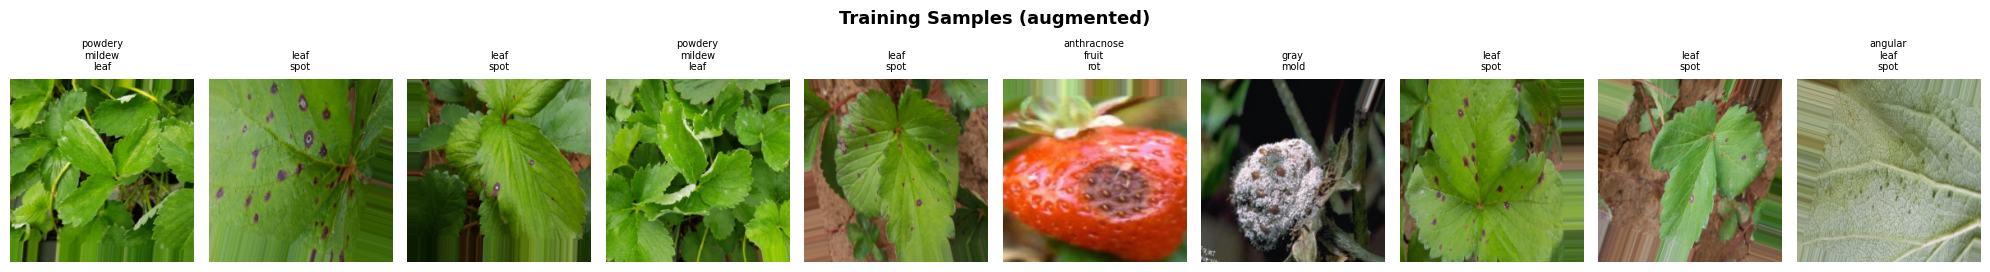

In [6]:
def show_samples(batches, n=10, title="Sample Images"):
    imgs, labels = next(batches)
    class_idx = {v: k for k, v in batches.class_indices.items()}

    fig, axes = plt.subplots(1, n, figsize=(20, 3))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    for i, (img, ax) in enumerate(zip(imgs[:n], axes)):
        # Undo VGG16 preprocessing to display correctly
        display = img + [103.939, 116.779, 123.68]
        display = np.clip(display / 255.0, 0, 1)[..., ::-1]  # BGR → RGB
        ax.imshow(display)
        ax.set_title(class_idx[np.argmax(labels[i])].replace("_", "\n"), fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_batches, title="Training Samples (augmented)")


## Step 7 — Helper Functions

In [7]:
def plot_history(history, title="Training History"):
    """Side-by-side accuracy and loss curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for ax, metric, ylabel in [
        (ax1, "accuracy", "Accuracy"),
        (ax2, "loss",     "Loss"),
    ]:
        ax.plot(history.history[metric],           label="Train",      linewidth=2)
        ax.plot(history.history[f"val_{metric}"],  label="Validation", linewidth=2, linestyle="--")
        ax.set_title(ylabel)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", normalize=False):
    """Plots a formatted confusion matrix. Set normalize=True for percentages."""
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
        fmt, title = ".2f", title + " (Normalized)"
    else:
        fmt = "d"

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title, fontsize=13, fontweight="bold")
    plt.colorbar()

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right", fontsize=9)
    plt.yticks(ticks, class_names, fontsize=9)

    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        val = f"{cm[i,j]:{fmt}}"
        plt.text(j, i, val, ha="center", va="center", fontsize=8,
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True label", fontsize=11)
    plt.xlabel("Predicted label", fontsize=11)
    plt.tight_layout()
    plt.show()


def evaluate_model(model, class_names, title="Model"):
    """Full evaluation: classification report + confusion matrices."""
    # Use a fresh loader with shuffle=False so class order is deterministic
    test_eval = make_loader(eval_datagen, TEST_DIR, shuffle=False)
    preds  = model.predict(test_eval, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_eval.classes

    print(f"\n{'='*60}")
    print(f"  {title} — Classification Report")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

    cm = confusion_matrix(y_true, y_pred)
    plot_confusion_matrix(cm, class_names, title=f"{title} — Confusion Matrix")
    plot_confusion_matrix(cm, class_names, title=f"{title} — Confusion Matrix", normalize=True)


print("✅ Helper functions defined.")


✅ Helper functions defined.


## Step 8 — Model A : Custom CNN (Baseline)

A simple 2-block CNN built from scratch.
Limited accuracy on small datasets.

**Architecture:**
```
Input(224×224×3)
  → Conv2D(32) → MaxPool
  → Conv2D(64) → MaxPool
  → Dropout(0.3)
  → Dense(128, relu)
  → Dense(7, softmax)
```


In [8]:
def build_custom_cnn(num_classes=7):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation="relu", padding="same",
                      input_shape=(224, 224, 3)),
        layers.MaxPool2D(2, 2),

        # Block 2
        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.MaxPool2D(2, 2),

        # Regularisation
        layers.Dropout(0.3),

        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ], name="CustomCNN")
    return model

cnn_model = build_custom_cnn()
cnn_model.summary()


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    25,690,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,710,535 (98.08 MB)

 Trainable params: 25,710,535 (98.08 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=3,
    restore_best_weights=True, verbose=1
)

print("Training Custom CNN...\n")
cnn_history = cnn_model.fit(
    train_batches,
    epochs=EPOCHS_CNN,
    validation_data=val_batches,
    callbacks=[early_stop],
    verbose=1,
)


Training Custom CNN...

Epoch 1/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 857s 6s/step - accuracy: 0.5117 - loss: 11.6419 - val_accuracy: 0.7008 - val_loss: 1.2719
Epoch 2/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 138s 950ms/step - accuracy: 0.6759 - loss: 1.6043 - val_accuracy: 0.7765 - val_loss: 1.0069
Epoch 3/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 144s 993ms/step - accuracy: 0.7559 - loss: 0.8473 - val_accuracy: 0.8409 - val_loss: 0.5874
Epoch 4/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 144s 994ms/step - accuracy: 0.8014 - loss: 0.7066 - val_accuracy: 0.7689 - val_loss: 0.7708
Epoch 5/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.8366 - loss: 0.5035 - val_accuracy: 0.8447 - val_loss: 0.4941
Epoch 6/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 145s 998ms/step - accuracy: 0.8510 - loss: 0.4700 - val_accuracy: 0.8106 - val_loss: 0.6064
Epoch 7/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.8807 - loss: 0.3823 - val_accuracy: 0.6364 - val_loss: 1.2279
Restoring model weights from the end of the best epoch: 5.


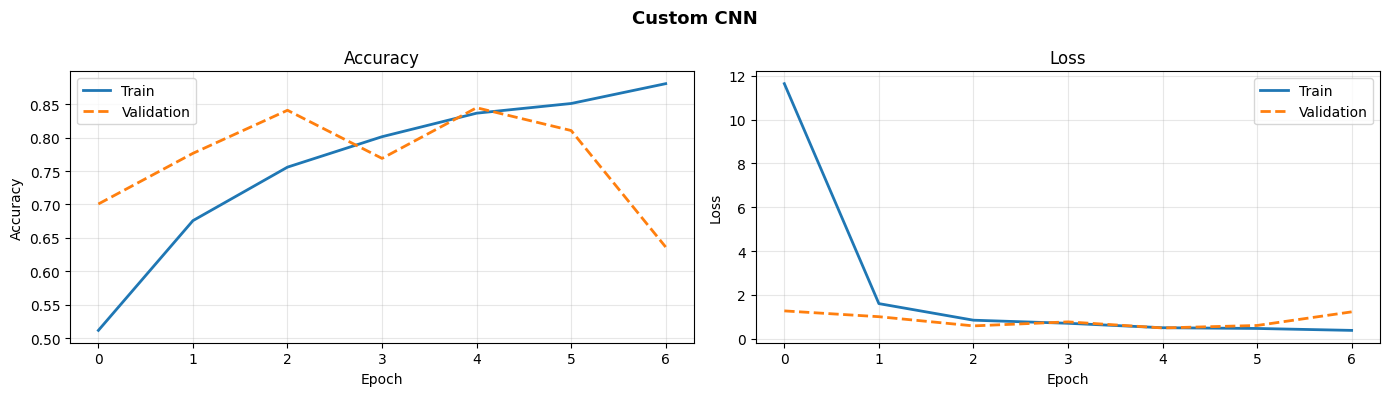

Found 549 images belonging to 7 classes.

  Custom CNN — Classification Report
                       precision    recall  f1-score   support

    angular_leaf_spot      0.678     0.789     0.730       147
anthracnose_fruit_rot      0.571     0.364     0.444        33
       blossom_blight      0.775     1.000     0.873        62
            gray_mold      0.596     0.917     0.723       145
            leaf_spot      0.818     0.222     0.350       162
 powdery_mildew_fruit      0.000     0.000     0.000         0
  powdery_mildew_leaf      0.000     0.000     0.000         0

             accuracy                          0.654       549
            macro avg      0.491     0.470     0.446       549
         weighted avg      0.702     0.654     0.615       549



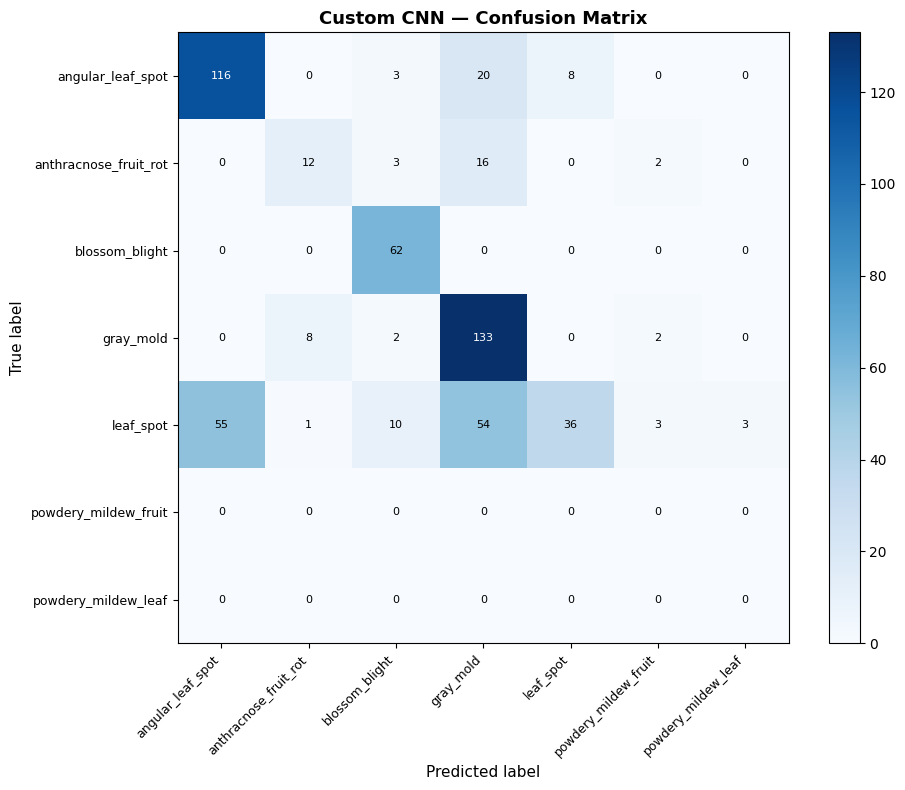

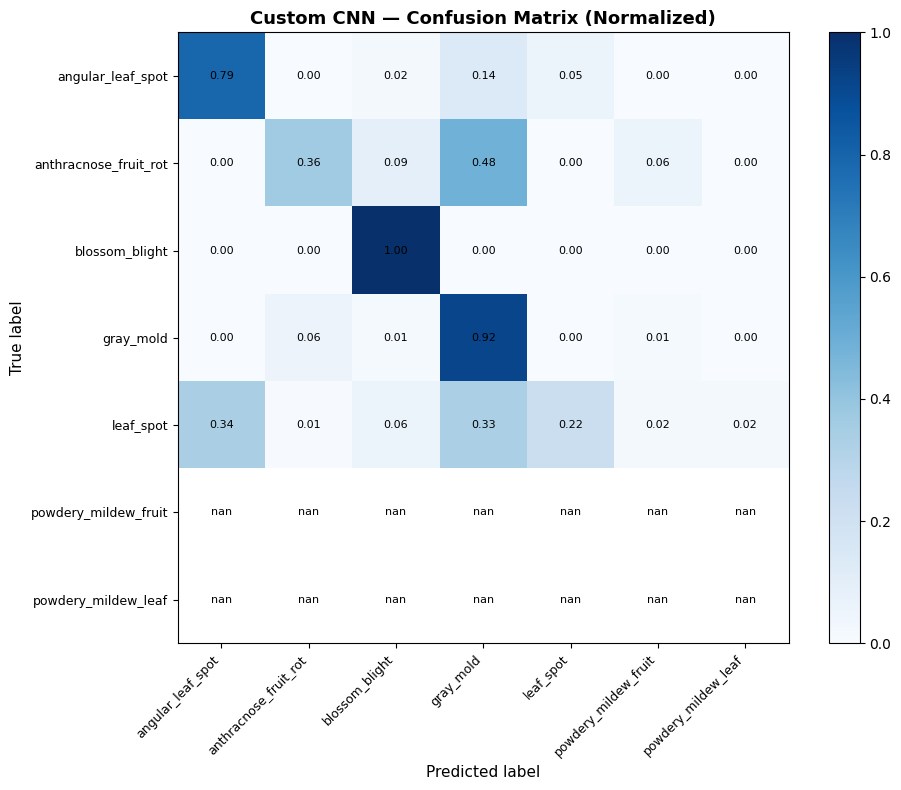

In [10]:
plot_history(cnn_history, title="Custom CNN")
evaluate_model(cnn_model, CLASSES, title="Custom CNN")


## Step 9 — Model B : Transfer Learning with VGG16

**Why Transfer Learning?**
VGG16 was trained on 1.2 million ImageNet images. It already knows how to detect
edges, textures, shapes, and complex patterns. We have reuse those learned features
and only train the final classification layer for our 7 disease classes.




In [11]:
def build_vgg16_model(num_classes=7):
    # include_top=False → removes VGG16's own 1000-class head
    base = tf.keras.applications.VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3),
    )
    base.trainable = False   # freeze all VGG16 weights

    model = models.Sequential([
        base,
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax"),
    ], name="VGG16_TransferLearning")
    return model

vgg_model = build_vgg16_model()
vgg_model.summary()

# Check: only the Dense layers should be trainable
trainable = sum(np.prod(w.shape) for w in vgg_model.trainable_weights)
total     = sum(np.prod(w.shape) for w in vgg_model.weights)
print(f"\nTrainable params : {trainable:,}")
print(f"Frozen params    : {total - trainable:,}")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "VGG16_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,271 (80.64 MB)

 Trainable params: 6,424,583 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


Trainable params : 6,424,583
Frozen params    : 14,714,688


In [12]:
vgg_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop_vgg = callbacks.EarlyStopping(
    monitor="val_loss", patience=3,
    restore_best_weights=True, verbose=1
)
lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, verbose=1
)

print("Training VGG16 Transfer Learning model...\n")
vgg_history = vgg_model.fit(
    train_batches,
    epochs=EPOCHS_TL,
    validation_data=val_batches,
    callbacks=[early_stop_vgg, lr_scheduler],
    verbose=1,
)


Training VGG16 Transfer Learning model...

Epoch 1/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 745s 5s/step - accuracy: 0.7034 - loss: 4.0652 - val_accuracy: 0.9053 - val_loss: 0.8964 - learning_rate: 1.0000e-04
Epoch 2/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 747s 5s/step - accuracy: 0.8559 - loss: 1.2635 - val_accuracy: 0.9242 - val_loss: 0.6930 - learning_rate: 1.0000e-04
Epoch 3/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 752s 5s/step - accuracy: 0.8897 - loss: 0.6523 - val_accuracy: 0.9432 - val_loss: 0.3354 - learning_rate: 1.0000e-04
Epoch 4/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 719s 5s/step - accuracy: 0.9193 - loss: 0.4466 - val_accuracy: 0.9394 - val_loss: 0.2485 - learning_rate: 1.0000e-04
Epoch 5/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 724s 5s/step - accuracy: 0.9248 - loss: 0.4335 - val_accuracy: 0.9318 - val_loss: 0.3558 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 4.


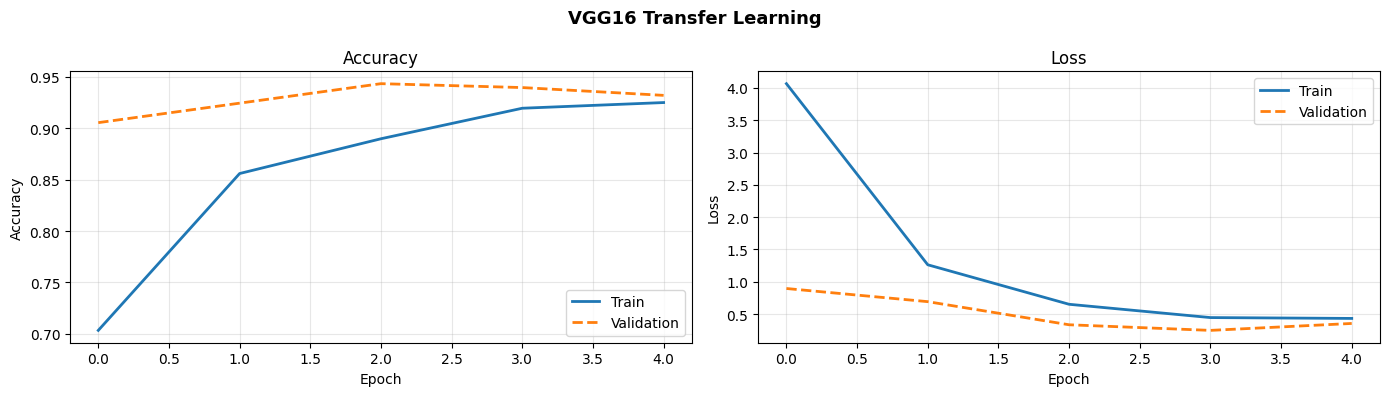

Found 549 images belonging to 7 classes.

  VGG16 Transfer Learning — Classification Report
                       precision    recall  f1-score   support

    angular_leaf_spot      0.772     0.966     0.858       147
anthracnose_fruit_rot      0.737     0.424     0.538        33
       blossom_blight      1.000     0.935     0.967        62
            gray_mold      0.866     0.890     0.878       145
            leaf_spot      0.941     0.685     0.793       162
 powdery_mildew_fruit      0.000     0.000     0.000         0
  powdery_mildew_leaf      0.000     0.000     0.000         0

             accuracy                          0.827       549
            macro avg      0.616     0.557     0.576       549
         weighted avg      0.870     0.827     0.837       549



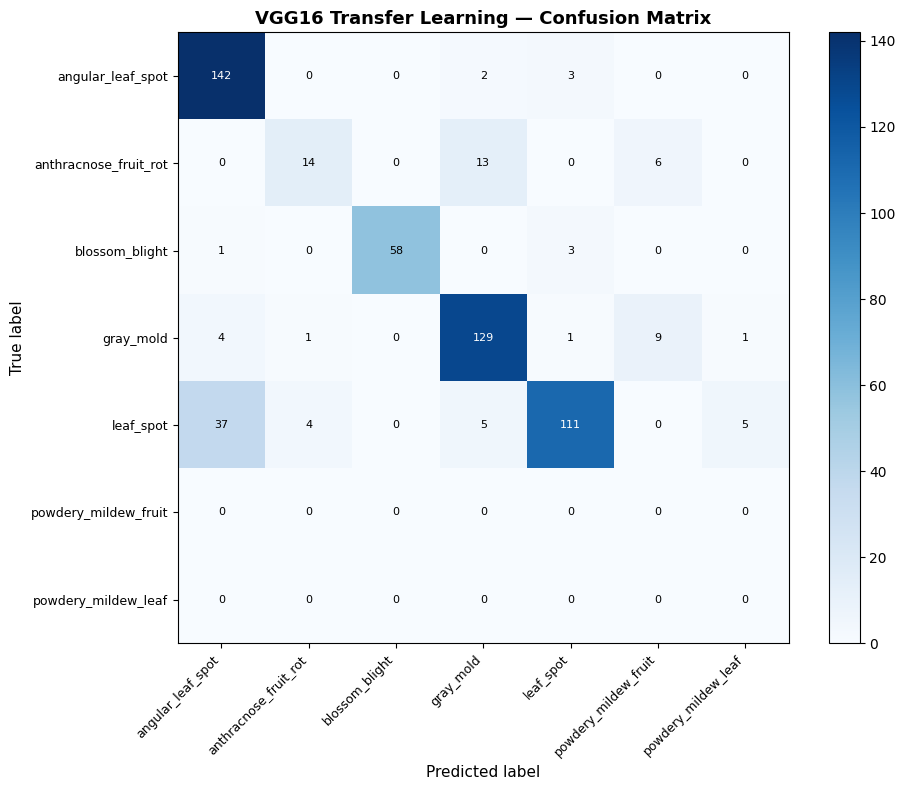

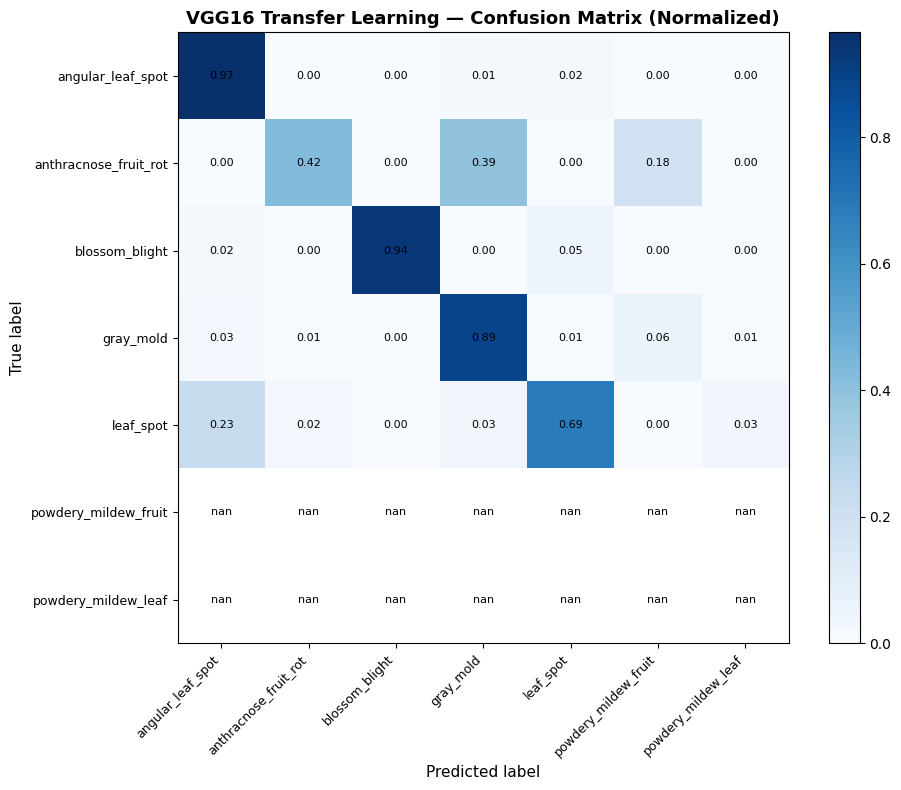

In [13]:
plot_history(vgg_history, title="VGG16 Transfer Learning")
evaluate_model(vgg_model, CLASSES, title="VGG16 Transfer Learning")


## Step 11 — Save the Trained Model

In [15]:
vgg_model.save(MODEL_SAVE_PATH)
print(f"✅ Model saved to: {MODEL_SAVE_PATH}")

# To reload later:
# loaded_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
# print("Model loaded successfully")


✅ Model saved to: /content/drive/MyDrive/strawberry_vgg16.keras


---

## Step 12 — Upload Your Own Image & Get a Prediction

Upload any strawberry plant photo and see what disease the model detects.
The cell will:
1. In output **choose a file** from your computer
2. Display the uploaded image
3. Run it through the **VGG16 model**
4. Show the **predicted disease** with confidence scores for all 7 classes


📤 Please upload a strawberry plant image...


Saving straw4.jpg to straw4.jpg

✅ Uploaded: straw4.jpg


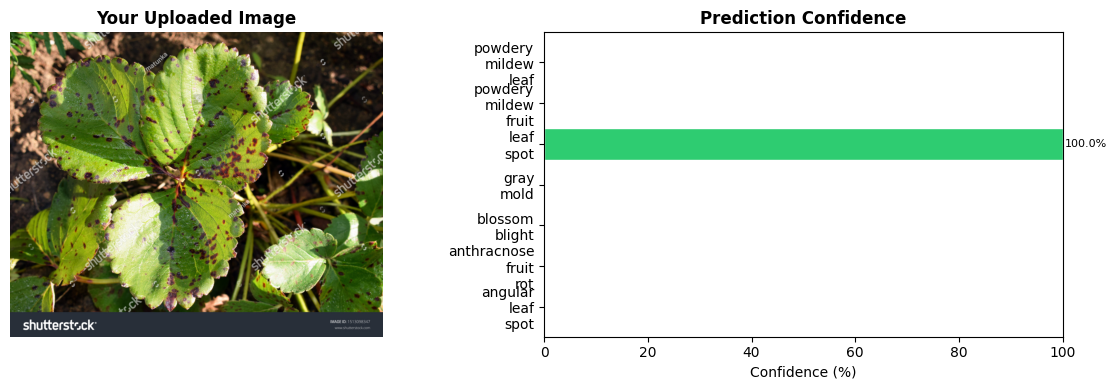


  🔍 PREDICTION : LEAF SPOT
  📊 CONFIDENCE : 100.0%


In [18]:
from google.colab import files
from PIL import Image
import io

# ── 1. Upload a file ─────────────────────────────────────────────────────
print("📤 Please upload a strawberry plant image...")
uploaded = files.upload()

if not uploaded:
    print("❌ No file uploaded.")
else:
    filename = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {filename}")

    # ── 2. Load and display the image ────────────────────────────────────
    img_pil = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(img_pil)
    axes[0].set_title("Your Uploaded Image", fontsize=12, fontweight="bold")
    axes[0].axis("off")

    # ── 3. Preprocess for VGG16 ──────────────────────────────────────────
    img_resized = img_pil.resize(IMG_SIZE)                         # resize to 224×224
    img_array  = np.array(img_resized, dtype=np.float32)           # to numpy
    img_array  = tf.keras.applications.vgg16.preprocess_input(img_array)  # VGG16 normalise
    img_array  = np.expand_dims(img_array, axis=0)                 # add batch dim → (1, 224, 224, 3)

    # ── 4. Run prediction ────────────────────────────────────────────────
    preds      = vgg_model.predict(img_array, verbose=0)[0]        # shape: (7,)
    top_idx    = np.argmax(preds)
    top_class  = CLASSES[top_idx]
    confidence = preds[top_idx] * 100

    # ── 5. Bar chart of all class probabilities ──────────────────────────
    colors = ["#2ecc71" if i == top_idx else "#bdc3c7" for i in range(len(CLASSES))]
    short_labels = [c.replace("_", "\n") for c in CLASSES]

    axes[1].barh(short_labels, preds * 100, color=colors, edgecolor="white")
    axes[1].set_xlabel("Confidence (%)", fontsize=10)
    axes[1].set_title("Prediction Confidence", fontsize=12, fontweight="bold")
    axes[1].set_xlim(0, 100)
    for i, v in enumerate(preds * 100):
        if v > 1:
            axes[1].text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

    # ── 6. Final verdict ─────────────────────────────────────────────────
    print("\n" + "="*50)
    print(f"  🔍 PREDICTION : {top_class.upper().replace('_', ' ')}")
    print(f"  📊 CONFIDENCE : {confidence:.1f}%")
    print("="*50)

    if confidence < 50:
        print("\n⚠️  Low confidence — the image may be unclear,")
        print("    not a strawberry plant, or a rare presentation.")




```
**Thankyou**
```

